### Astrostatistic Lecture 12 

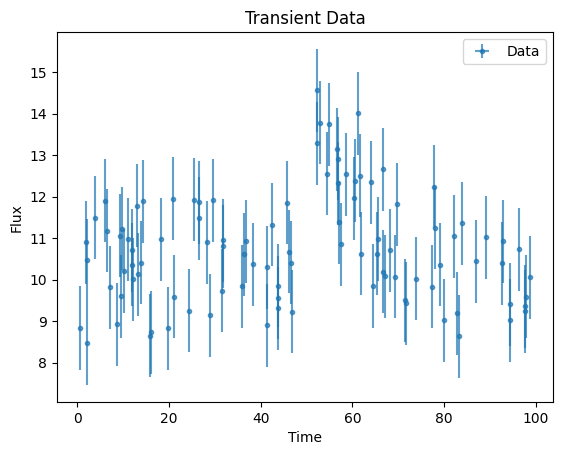

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy import stats
import emcee
import corner
import dynesty
from sklearn.neighbors import KernelDensity
import matplotlib.patches as mpatches
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
plt.rcParams['figure.facecolor'] = 'white' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'         
plt.rcParams['axes.labelcolor'] = 'black'  
plt.rcParams['text.color'] = 'black'  
plt.rcParams['xtick.color'] = 'black'           
plt.rcParams['ytick.color'] = 'black'

#same data as Lecture 11
data = np.load('/home/ricca/astrostat/astrostatistics_bicocca_2026/solutions/transient.npy') #load data
time = data[:,0]
flux = data[:,1]
errors = np.ones_like(flux)

plt.errorbar(time, flux, errors, 0,  '.', alpha = 0.7, label = 'Data')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.title('Transient Data')
plt.show()

In [10]:
#now we need to do it using dynesty so using nested sampling 
def model_exp(A, b, t, t0, alfa):   #define the model to use
    return np.where(t < t0, b, b + A * np.exp(-alfa*(t - t0)))

#use a different model and check which is bettere
def gaussian (A, b, t, t0, sigma):
    return b+A*np.exp(-((t-t0)**2)/(2*sigma**2))

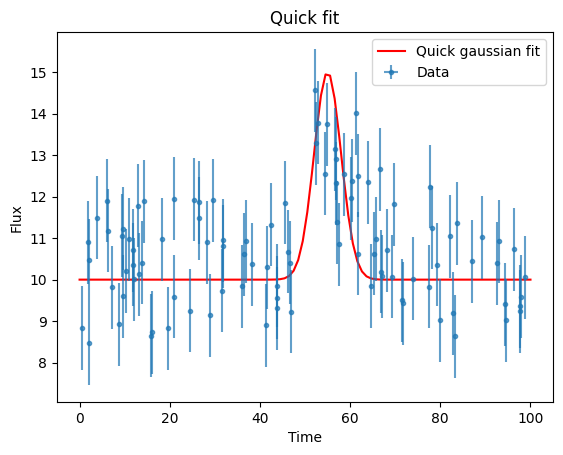

In [ ]:
#try an initial stupid fit with both models
tgrid=np.linspace(0,100,100)
t0_quick=55
A_quick=5
b_quick=10
sigma=3
flux_quick=gaussian(A_quick, b_quick, tgrid, t0_quick, sigma)

plt.plot(tgrid, flux_quick, 'r', label = 'Quick gaussian fit')
plt.errorbar(time, flux, errors, 0,  '.', alpha = 0.7, label = 'Data')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.title('Quick fit')
plt.show()

In [19]:
#different model needs different priors for the parameters
def gauss_transformer (x):
    a = stats.uniform.ppf(x[0], 0, 50)
    b = stats.uniform.ppf(x[1], 0, 50)
    t0 = stats.uniform.ppf(x[2], 50, 60)    #see the plot of the data to know where the gaussian peak will be 
    log_sigma = stats.uniform.ppf(x[3], 0, 2)  # ok range for sigma 
    sigma = np.exp(log_sigma)
    if sigma < 1e-6:
        return -np.inf    #similar to what we had on alpha
    return np.array([a, b, t0, sigma])

def log_likelihood(theta, t, data, errors, model):     #log of a gaussian likelihood
    if model == 'exp':
        A, b, t0, log_alfa = theta
        alfa = np.exp(log_alfa)
        m = model_exp(A, b, t, t0, alfa)    #likelihood of the model given the data we have and the errors (equal but whatever)
        return -0.5 * np.sum((data - m)**2 / errors**2 +  np.log(2*np.pi*errors**2))
    if model == 'gauss':
        A, b, t0, sigma = theta
        m = gaussian(A, b, t, t0, sigma)
        return -0.5 * np.sum((data - m)**2 / errors**2 + np.log(2*np.pi*errors**2))
    else:
        raise ValueError("This model doesn't exist")
    
def transformer (x):
    a = stats.uniform.ppf(x[0], 0, 50)
    b = stats.uniform.ppf(x[1], 0, 50)
    t0 = stats.uniform.ppf(x[2], 0, 100)
    alfa = stats.uniform.ppf(x[3], -5, 5)
    return np.array([a, b, t0, alfa])

In [12]:
ndim=4

sampler = dynesty.NestedSampler(log_likelihood, transformer, ndim, logl_args=[time, flux, errors, 'exp'])
sampler.run_nested()
sresults = sampler.results

3755it [00:34, 103.17it/s, bound: 82 | nc: 22 | ncall: 63446 | eff(%):  5.918 | loglstar:   -inf < -179.030 <    inf | logz: -188.018 +/-  0.127 | dlogz: 37.734 >  0.509]    /home/ricca/astrostat/astrostatistics_bicocca_2026/venv/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
/home/ricca/astrostat/astrostatistics_bicocca_2026/venv/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be c

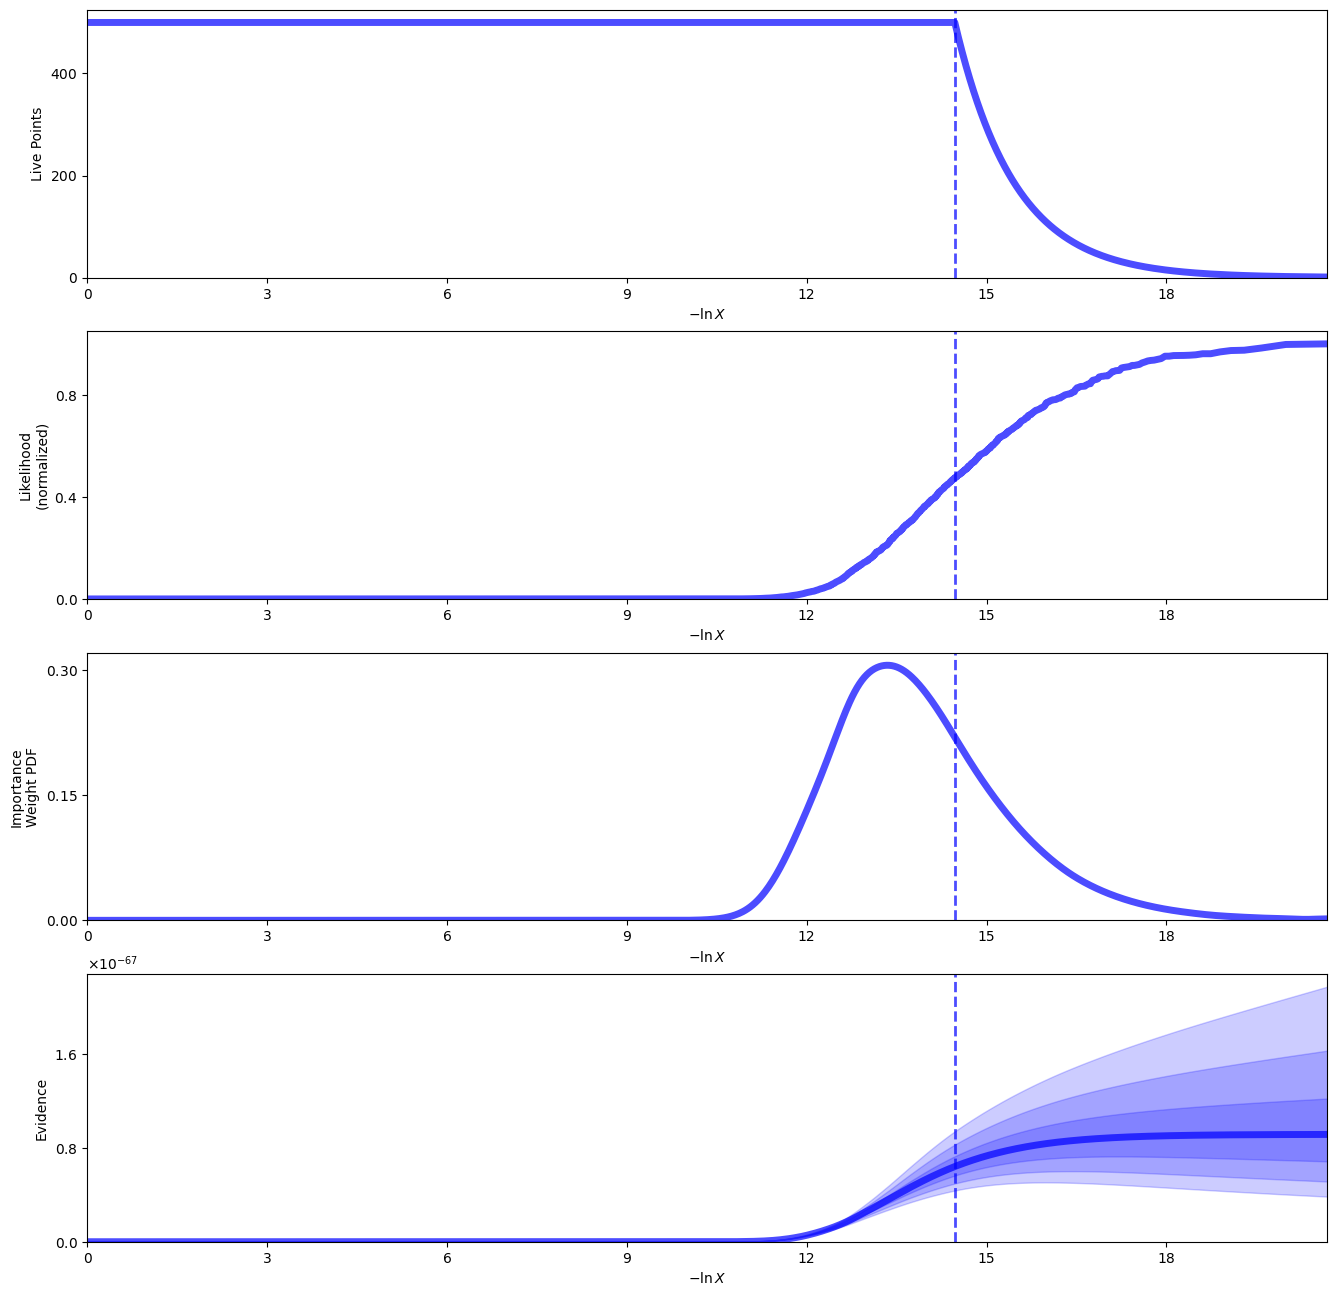

In [13]:
rfig, raxes = dyplot.runplot(sresults)

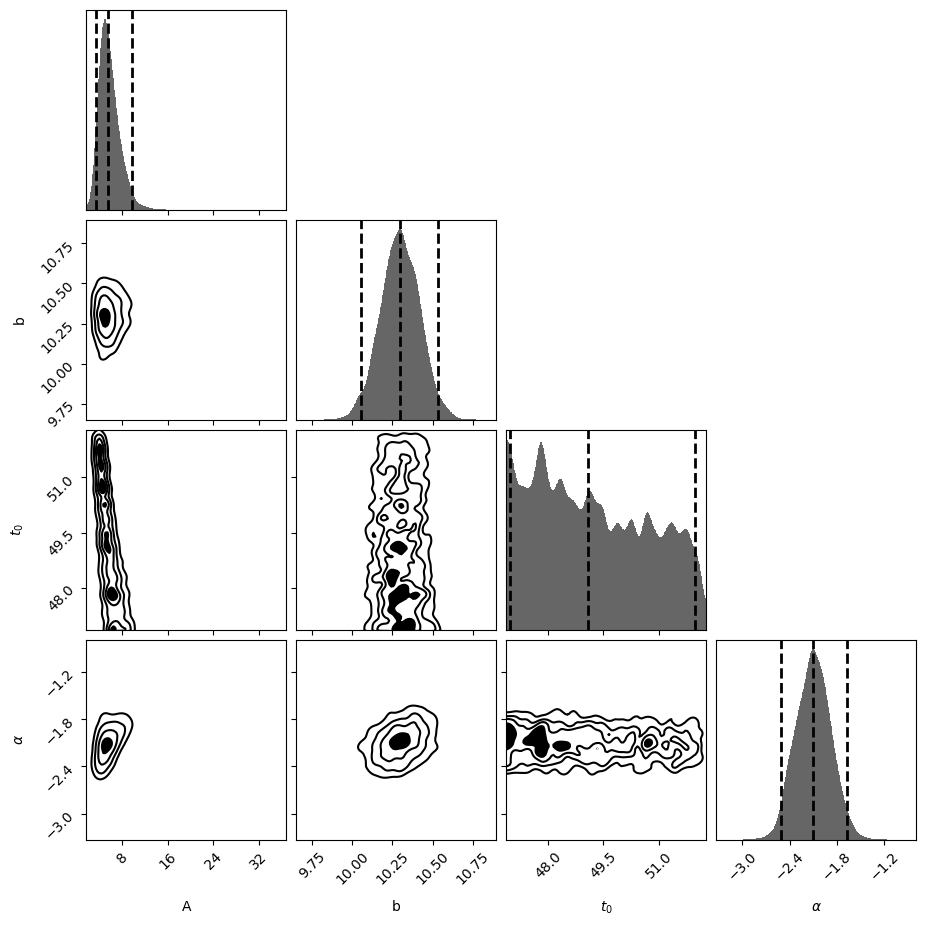

In [14]:
cfig, caxes = dyplot.cornerplot(sresults, labels=['A', 'b', r'$t_0$', r'$\alpha$'])

Bayesian evidence 9.130126348853271e-68
68% parameter credible regions are:

 A [4.1446742844359665, 7.372830126468669]

 b [10.179623598601808, 10.417778821135757]

 t0 [47.54082647502844, 51.111357795700165]

 alfa [-2.325407340038987, -1.8809206708483859]


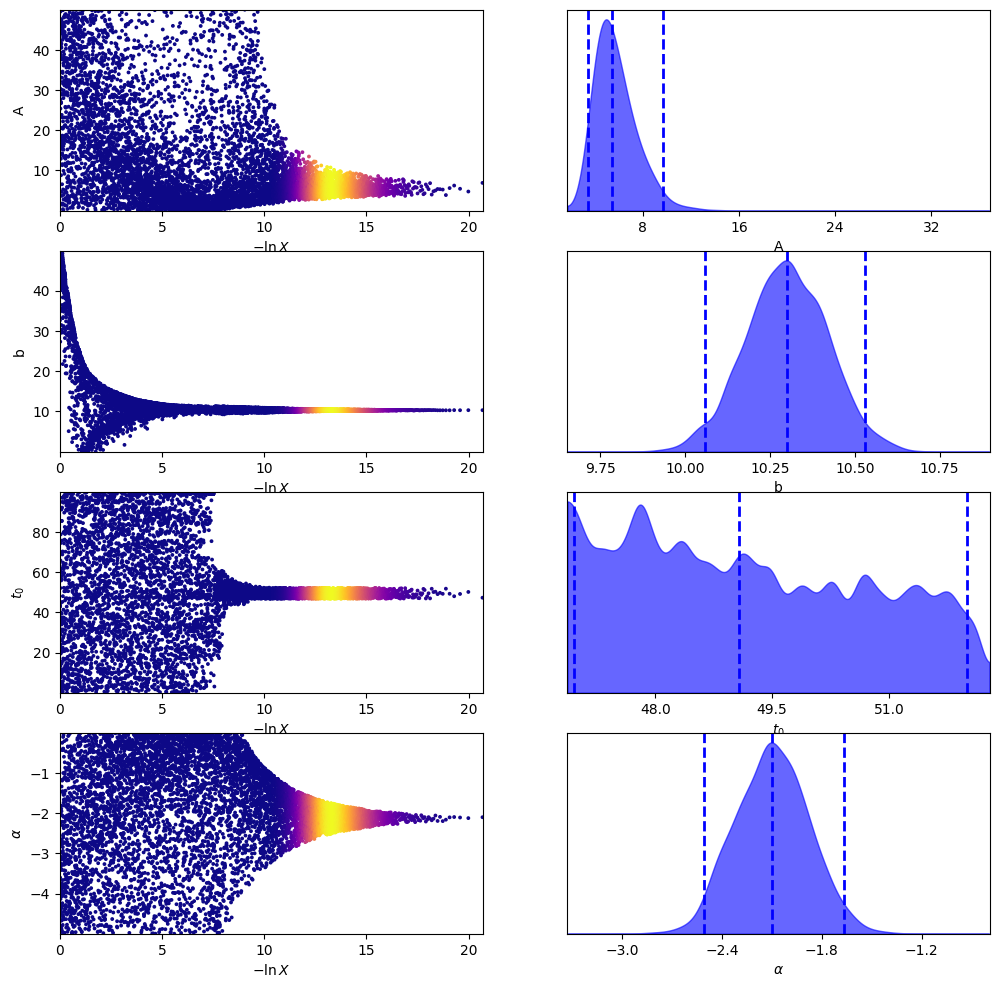

In [15]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

samples_equal = dyfunc.resample_equal(samples, weights)
tfig, taxes = dyplot.traceplot(sresults, labels=['A', 'b', r'$t_0$', r'$\alpha$'])
labels = ['A', 'b', 't0', 'alfa']

quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:')
for i in range(ndim):
    print('\n '+ str(labels[i]) + ' '+ str(quantiles[i]))

### Second model: gaussian fitting

In [20]:
ndim=4

gauss_sampler = dynesty.NestedSampler(log_likelihood, gauss_transformer, ndim, logl_args=[time, flux, errors, 'gauss'])
gauss_sampler.run_nested()
gauss_results = gauss_sampler.results

2043it [00:06, 314.65it/s, bound: 3 | nc: 17 | ncall: 19964 | eff(%): 10.233 | loglstar:   -inf < -341.084 <    inf | logz: -350.562 +/-  0.132 | dlogz: 188.404 >  0.509]   /home/ricca/astrostat/astrostatistics_bicocca_2026/venv/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
2643it [00:10, 290.77it/s, bound: 14 | nc: 3 | ncall: 25585 | eff(%): 10.330 | loglstar:   -inf < -212.691 <    inf | logz: -221.623 +/-  0.127 | dlogz: 64.005 >  0.509]  /home/ricca/astrostat/astrostatistics_bicocca_2026/venv/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor fo

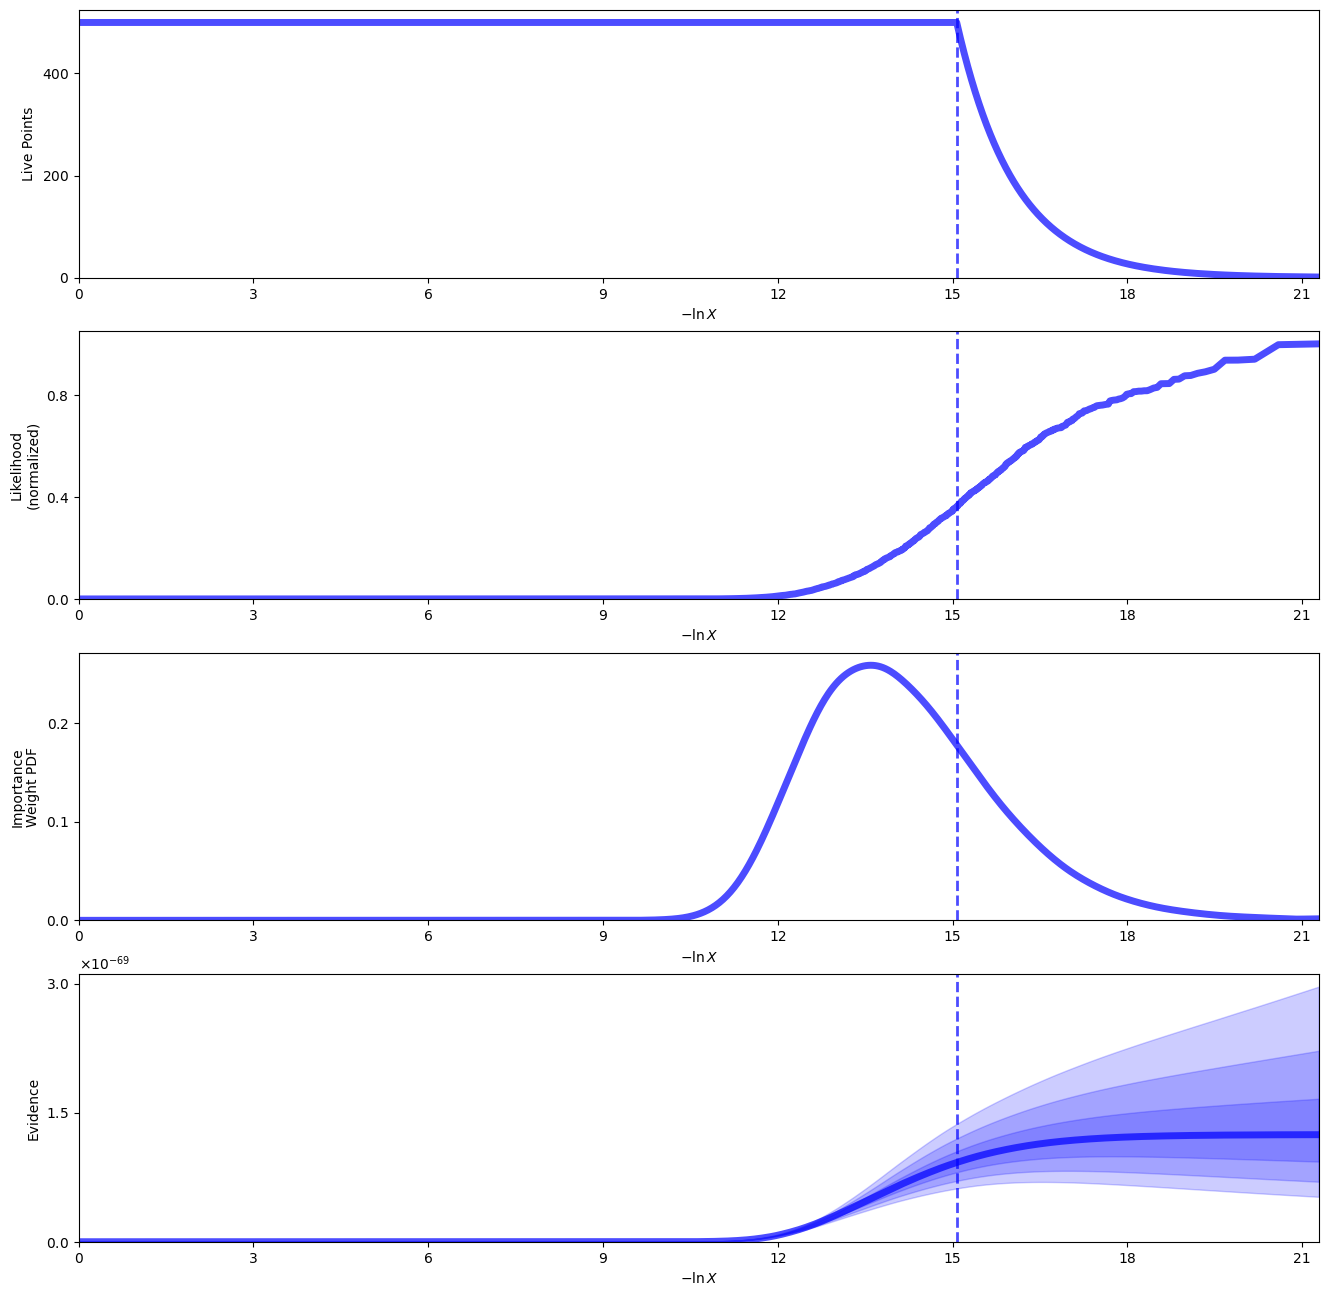

In [21]:
rfig, raxes = dyplot.runplot(gauss_results)

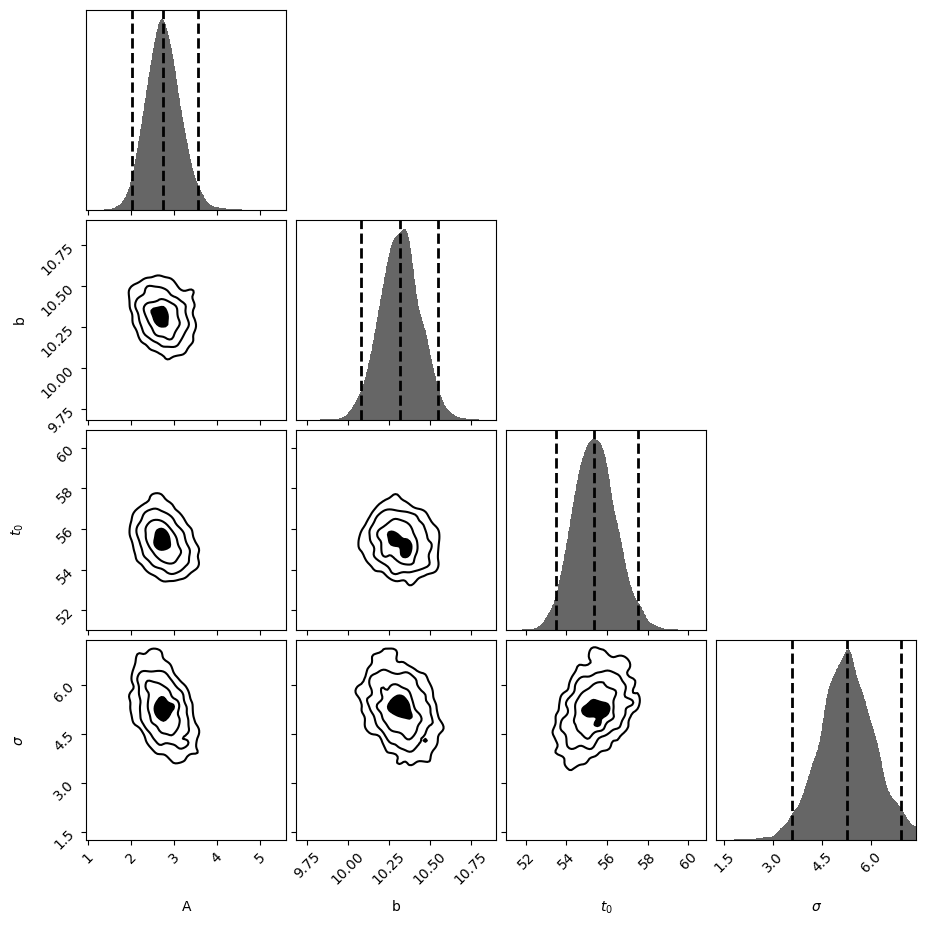

In [22]:
cfig, caxes = dyplot.cornerplot(gauss_results, labels=['A', 'b', r'$t_0$', r'$\sigma$'])

Bayesian evidence 1.2437495733217702e-69
68% parameter credible regions are:

 A [2.3695442894220515, 3.136583387838951]

 b [10.197243669300052, 10.441473270579912]

 t0 [54.368394673620024, 56.44071618238173]

 sigma [4.458112984685083, 6.075500224060265]


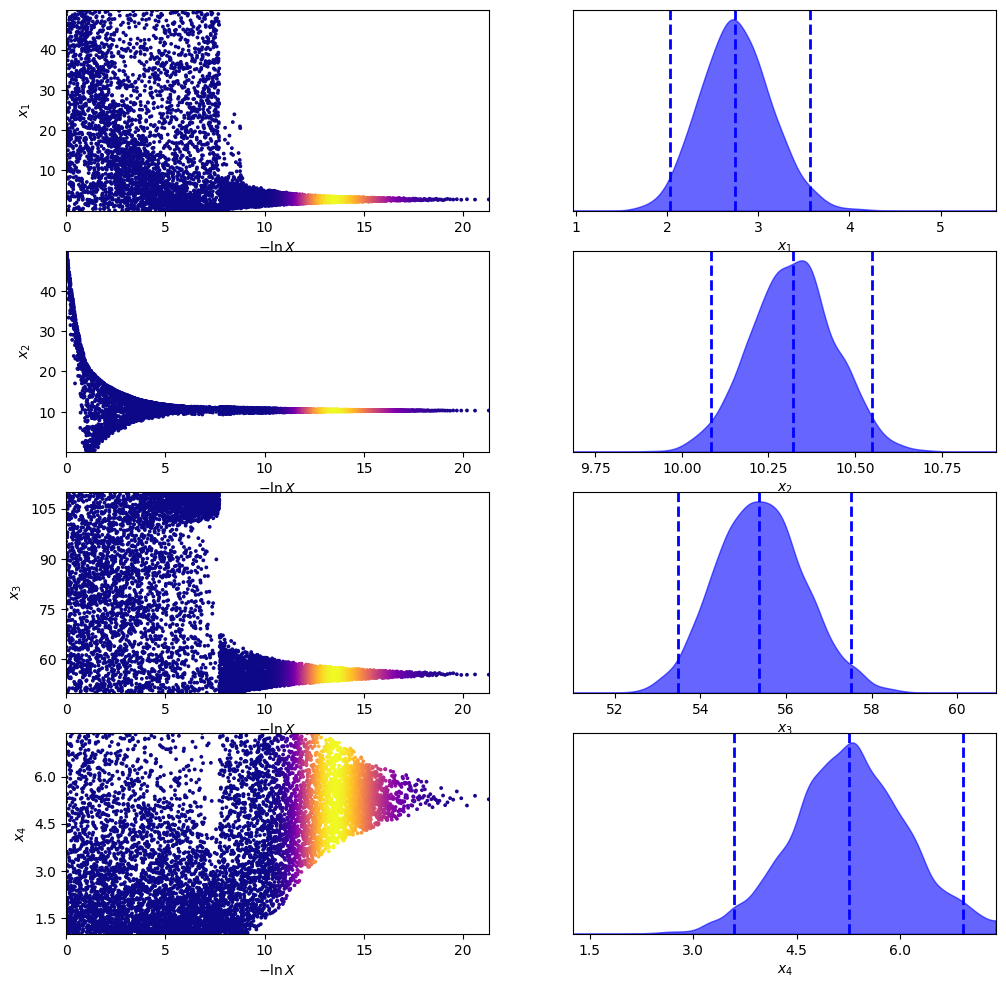

In [23]:
gauss_samples = gauss_results.samples  # samples
weights = np.exp(gauss_results.logwt - gauss_results.logz[-1])  # normalized weights

evidence = gauss_results.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

samples_equal = dyfunc.resample_equal(gauss_samples, weights)
tfig, taxes = dyplot.traceplot(gauss_results)
labels = ['A', 'b', 't0', 'sigma']

quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in gauss_samples.T]
print('68% parameter credible regions are:')
for i in range(ndim):
    print('\n '+ str(labels[i]) + ' '+ str(quantiles[i]))